In [23]:
from typing import List, TypedDict
from langgraph.graph import StateGraph
# StateGraph is a framework that help to design and manage the flow of tasks using graph structure.

In [24]:
class AgentState(TypedDict): 
    name: str
    values: List[int] 
    operation: str
    result: str

In [25]:
def process_node(state: AgentState) -> AgentState:
    """
    Single node that processes the input, performs the operation,
    and returns the formatted output.
    """
    name = state["name"]
    values = state["values"]
    operation = state["operation"]
    
    # Perform the calculation based on operation
    if operation == "+":
        answer = sum(values)
    elif operation == "*":
        answer = 1
        for val in values:
            answer *= val
    else:
        raise ValueError(f"Unsupported operation: {operation}. Use '+' or '*'")
    
    # Format the output
    result = f"Hi {name}, your answer is: {answer}"
    
    # Return updated state
    return {"result": result}


In [26]:
graph = StateGraph(AgentState)
graph.add_node('Processor', process_node)
graph.set_entry_point('Processor')
graph.set_finish_point('Processor')
app = graph.compile()

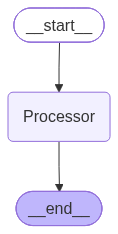

In [27]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [31]:
result = app.invoke({"name": "Jacksparow", "values": [1, 2, 3, 4], "operation": "+"})

In [32]:
result["result"]

'Hi Jacksparow, your answer is: 10'